# Online UFTC B-747 engine-out trim-hold experiment — **Phase 4 (composite Lyapunov monitor)**

This notebook is the Phase 4 sibling of `example_uftc_b747_engine_failure_phase3.ipynb`. The full Phase 3 stack — L2 AA-INDI inner + L3 IADP middle + FDD/CUSUM + L4 D-SAC outer with the pre-trained actor/critic from `artifacts/dsac/b747_engine_out_v1/` — runs unchanged on the same left-outer-engine failure scenario.

What Phase 4 adds on top:

1. **`enable_monitor=True`.** A per-tick composite Lyapunov runtime monitor that reads `VState = (V_HJ, V_INDI, V_iADP, V_DSAC, V_FDD)` from each layer, weights them into a scalar `V_total`, and compares against a closed-form UUB radius `mu_uub_pred = ‖M^{-1} d‖_c` derived from the (Metzler/Hurwitz) coupling matrix `M = diag(a) - eps`.
2. **Per-plant calibrated `MonitorConfig`.** The default `d_disturbance = (0.05,)*5` is far too tight for the nonlinear B-747 — `V_INDI` alone reaches order 10 because of sensor noise + reference-tracking residuals. We retune `d_disturbance = (20.0,)*5` and re-weight `c_weights = (0.0, 0.4, 0.0, 0.3, 0.3)` so `V_HJ = 0` (L1 disabled) and `V_iADP = 0` (vacuous: stock IADP doesn't expose `P_critic`). The active components in this demo are **`V_INDI + V_DSAC + V_FDD`**.
3. **3-level alarm state machine** with hysteresis and cooldown — `OK` / `WARN` / `CRITICAL`.
4. **Macro-action dispatcher.** Each WARN/CRITICAL transition emits a list of MacroActions (`force_rls_reset`, `freeze_l4_learning`, `degrade_reference_to_hold`, `request_actuator_hold`) that the controller maps onto explicit method calls on L1/L3/L4.
5. **Numerical UUB certificate** run inline via `tensoraerospace.agent.uftc.monitor.certificate.run_certificate(cfg, rollouts={...})`.

Phase 1 (no L4) and Phase 3 (random / pre-trained L4) baselines are reused unchanged; the 4-way RMSE comparison documents whether the monitor improves yaw/pitch tracking via well-timed `force_rls_reset` triggers, or matches Phase 3 with no harm.

## 1. Imports and simulation settings

In [1]:
import warnings
warnings.filterwarnings("ignore")

import math

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve

from tensoraerospace.aerospacemodel.b747.nonlinear import B747Configuration, trim
from tensoraerospace.aerospacemodel.b747.nonlinear.damage.state import B747DamageState
from tensoraerospace.aerospacemodel.b747.nonlinear.dynamics import b747_ode_6dof
from tensoraerospace.aerospacemodel.b747.nonlinear.damage import LEFT_OUTER_ENGINE_FAILURE
from tensoraerospace.aerospacemodel.b747.nonlinear.engine import JT9DEngine
from tensoraerospace.aerospacemodel.b747.nonlinear.params import (
    default_parameters, isa_speed_of_sound_ft_s,
)
import importlib
import tensoraerospace.agent.uftc.controller as uftc_controller_module

# Jupyter can keep the old UFTCController class after editing the library.
# Reload here so full-state UFTC uses the n_state / omega_indices split.
importlib.reload(uftc_controller_module)
from tensoraerospace.agent.uftc.controller import UFTCConfig, UFTCController
from tensoraerospace.agent.aa_indi.model import AAINDIConfig
from tensoraerospace.agent.iadp.model import IADPConfig
from tensoraerospace.agent.uftc.fdd.detector import FDDConfig
from tensoraerospace.envs.b747_nonlinear import NonlinearB747Env

DT = 0.05
TOTAL_TIME = 300.0
DAMAGE_TIME = 10.0
N_EP = int(TOTAL_TIME / DT)
DAMAGE_STEP = int(DAMAGE_TIME / DT)

V_REF_FT_S = 674.0
ALT_REF_FT = 20_000.0
PSI_REF_DEG = 0.0

# Stricter final-window bands than the tuned ET-DHP notebook baseline.
SPEED_HOLD_BAND_FT_S = 0.05
ALT_HOLD_BAND_FT = 0.01
PITCH_HOLD_BAND_DEG = 0.005
YAW_HOLD_BAND_DEG = 0.01
ROLL_HOLD_BAND_DEG = 0.01

# Current tuned ET-DHP example baseline for the same 300 s scenario.
ETDHP_BASELINE = {
    "speed_rmse": 0.076,
    "alt_rmse": 2.370,
    "pitch_rmse": 0.0010,
    "yaw_rmse": 0.3905,
    "roll_rmse": 0.0140,
    "speed_drift": 0.0023,
    "alt_drift": 0.0740,
}

# UFTC residual authority around the envelope allocator command. The outer
# envelope holds the equilibrium; UFTC supplies small online rate corrections.
UFTC_RESIDUAL_SCALE = np.array([
    0.0,               # elevator residual, rad (envelope owns altitude hold)
    math.radians(0.05), # aileron residual, rad
    math.radians(0.05), # rudder residual, rad
    0.0,               # throttle residual (envelope owns speed/altitude hold)
], dtype=np.float64)

print(f"Evaluation length: {TOTAL_TIME:.0f} s ({N_EP} steps @ dt={DT}s)")
print(f"Damage trigger : t = {DAMAGE_TIME:.0f} s (step {DAMAGE_STEP})")
print("Final-window UFTC target bands:")
print(f"  RMSE |V - V0| <= {SPEED_HOLD_BAND_FT_S:.3f} ft/s")
print(f"  RMSE |h - h0| <= {ALT_HOLD_BAND_FT:.2f} ft")
print(f"  RMSE attitude theta/psi/phi <= {PITCH_HOLD_BAND_DEG:.3f}/"
      f"{YAW_HOLD_BAND_DEG:.3f}/{ROLL_HOLD_BAND_DEG:.3f} deg")


Evaluation length: 300 s (6000 steps @ dt=0.05s)
Damage trigger : t = 10 s (step 200)
Final-window UFTC target bands:
  RMSE |V - V0| <= 0.050 ft/s
  RMSE |h - h0| <= 0.01 ft
  RMSE attitude theta/psi/phi <= 0.005/0.010/0.010 deg


## 2. Cruise and one-engine-out trim

In [2]:
trim_result = trim(altitude_ft=ALT_REF_FT, V_ft_s=V_REF_FT_S,
                   config=B747Configuration.NOMINAL)
assert trim_result.converged

healthy_trim_state = trim_result.to_state()
delta_e_trim_rad = float(trim_result.elevator_rad)
throttle_trim = float(trim_result.throttle)
theta_ref_deg = math.degrees(trim_result.theta_rad)
healthy_trim_action = np.array([
    delta_e_trim_rad,
    0.0,
    0.0,
    throttle_trim,
], dtype=np.float64)

engine_params = default_parameters(B747Configuration.NOMINAL)
engine_model = JT9DEngine(
    n_engines=4,
    sls_thrust_per_engine_lb=engine_params.engine_thrust_max_lb / 4.0,
    idle_frac=engine_params.engine_idle_frac,
    spool_tau_s=engine_params.engine_tau_s,
)

engine_out_params = default_parameters(B747Configuration.NOMINAL)
engine_out_damage_state = B747DamageState.healthy()
engine_out_damage_state.engines_mu[1] = 0.0
engine_out_params.damage_state = engine_out_damage_state
throttle_engine_out_estimate = min(throttle_trim * 4.0 / 3.0, 1.0)


def engine_out_state_from_vars(alpha_rad, beta_rad, theta_rad):
    return np.array([
        V_REF_FT_S * math.cos(alpha_rad) * math.cos(beta_rad),
        V_REF_FT_S * math.sin(beta_rad),
        V_REF_FT_S * math.sin(alpha_rad) * math.cos(beta_rad),
        0.0, 0.0, 0.0,
        0.0, theta_rad, 0.0,
        0.0, 0.0, -ALT_REF_FT,
    ], dtype=np.float64)


def engine_out_trim_residual(z):
    alpha_rad, beta_rad, theta_rad, de_rad, da_rad, dr_rad, throttle_cmd = z
    x = engine_out_state_from_vars(alpha_rad, beta_rad, theta_rad)
    u = np.array([
        de_rad, da_rad, dr_rad, np.clip(throttle_cmd, 0.0, 1.0),
    ], dtype=np.float64)
    dx = b747_ode_6dof(x, u, 0.0, engine_out_params)
    return np.array([dx[0], dx[1], dx[2], dx[3], dx[4], dx[5], dx[11]], dtype=np.float64)


z0 = np.array([
    trim_result.alpha_rad,
    math.radians(-0.44),
    trim_result.theta_rad,
    delta_e_trim_rad,
    math.radians(-4.4),
    math.radians(-2.64),
    throttle_engine_out_estimate,
], dtype=np.float64)
engine_out_solution, info, ier, msg = fsolve(
    engine_out_trim_residual, z0, full_output=True, xtol=1e-10, maxfev=2_000,
)
engine_out_residual_norm = float(np.linalg.norm(info["fvec"]))
assert ier == 1 and engine_out_residual_norm < 1e-6, msg

(
    alpha_engine_out_rad,
    beta_engine_out_rad,
    theta_engine_out_rad,
    delta_e_engine_out_rad,
    delta_a_engine_out_rad,
    delta_r_engine_out_rad,
    throttle_engine_out,
) = engine_out_solution
throttle_engine_out = float(np.clip(throttle_engine_out, 0.0, 1.0))
engine_out_trim_state = engine_out_state_from_vars(
    alpha_engine_out_rad, beta_engine_out_rad, theta_engine_out_rad,
)
engine_out_trim_action = np.array([
    delta_e_engine_out_rad,
    delta_a_engine_out_rad,
    delta_r_engine_out_rad,
    throttle_engine_out,
], dtype=np.float64)

print(f"Healthy trim @ FL200, V={V_REF_FT_S:.0f} ft/s:")
print(f"  alpha = theta = {theta_ref_deg:+.3f} deg")
print(f"  delta_e_trim  = {math.degrees(delta_e_trim_rad):+.3f} deg")
print(f"  throttle_trim = {throttle_trim:.4f}")
print("Static left-outer-engine-out trim used by the UFTC envelope allocator:")
print(f"  beta = {math.degrees(beta_engine_out_rad):+.3f} deg")
print(f"  de/da/dr/throttle = {math.degrees(delta_e_engine_out_rad):+.3f} deg, "
      f"{math.degrees(delta_a_engine_out_rad):+.3f} deg, "
      f"{math.degrees(delta_r_engine_out_rad):+.3f} deg, {throttle_engine_out:.4f}")
print(f"  trim residual norm = {engine_out_residual_norm:.2e}")


Healthy trim @ FL200, V=674 ft/s:
  alpha = theta = +3.603 deg
  delta_e_trim  = -0.722 deg
  throttle_trim = 0.5549
Static left-outer-engine-out trim used by the UFTC envelope allocator:
  beta = -0.440 deg
  de/da/dr/throttle = -0.722 deg, -4.403 deg, -2.642 deg, 0.7575
  trim residual norm = 8.27e-15


## 3. UFTC full-state transform, controller and action composition

The UFTC controller receives the explicit regulation state
`[eV, eh, e_theta, e_psi, e_phi, e_beta, p, q, r]`. The middle/FDD layers use all nine states, while the inner AA-INDI loop uses `omega_indices=[6, 7, 8]` to extract only `[p, q, r]`.


In [3]:
def make_env(damage_profile=None, n_steps=N_EP + 5):
    return NonlinearB747Env(
        trim_at=(ALT_REF_FT, V_REF_FT_S),
        number_time_steps=n_steps,
        dt=DT,
        integrator="rk4",
        action_space="virtual",
        config=B747Configuration.NOMINAL,
        damage_profile=damage_profile,
    )


# Explicit UFTC state:
#   [eV, eh, e_theta, e_psi, e_phi, e_beta, p, q, r]
# The first six entries are normalized regulation errors; p/q/r stay in rad/s
# so the AA-INDI inner loop keeps physical angular-rate units.
UFTC_STATE_SCALE = np.array([
    25.0,
    250.0,
    math.radians(3.0),
    math.radians(8.0),
    math.radians(8.0),
    math.radians(2.0),
    1.0,
    1.0,
    1.0,
], dtype=np.float64)
N_UFTC_STATE = int(UFTC_STATE_SCALE.size)
UFTC_OMEGA_INDICES = [6, 7, 8]
UFTC_REFERENCE = np.zeros(N_UFTC_STATE, dtype=np.float64)

# Full-state warm-start matrices for IADP/FDD. These are only coarse local
# sensitivities; online RLS keeps adapting them during the episode.
UFTC_F_INIT = np.eye(N_UFTC_STATE, dtype=np.float64) * 0.99
UFTC_F_INIT[2, 7] = DT / UFTC_STATE_SCALE[2]  # theta_error integrates q
UFTC_F_INIT[3, 8] = DT / UFTC_STATE_SCALE[3]  # psi_error integrates r
UFTC_F_INIT[4, 6] = DT / UFTC_STATE_SCALE[4]  # phi_error integrates p

UFTC_G_INIT = np.zeros((N_UFTC_STATE, 4), dtype=np.float64)
UFTC_G_INIT[0] = [0.0, 0.0, 0.0, 0.08]
UFTC_G_INIT[1] = [-0.02, 0.0, 0.0, 0.03]
UFTC_G_INIT[6] = [0.00, 0.30, 0.00, 0.00]
UFTC_G_INIT[7] = [0.40, 0.00, 0.00, 0.10]
UFTC_G_INIT[8] = [0.00, 0.05, 0.30, 0.00]
UFTC_G_INNER = UFTC_G_INIT[UFTC_OMEGA_INDICES].copy()


# Phase-3-specific knobs for the L4 D-SAC outer loop.
#   l4_action_scale=0.05  --> small reference perturbation around the envelope command
#   l4_eval_mode=True     --> deterministic actor mean, no SGD step in learn()
#   l4_n_ref_dim=0        --> defaults to n_state (=9) so r_eff has the same
#                              shape as UFTC_REFERENCE
#   l4_trim_free          --> uses the source notebook's UFTC_STATE_SCALE indices:
#                              V_idx=0 (eV), gamma_idx=1 (eh proxy), alpha_idx=2
#                              (e_theta) and q_idx=7 (q). With eval_mode=True
#                              and random weights this mostly passes through
#                              the base reference; the point is to show the API
#                              wiring is plumbed all the way through.
L4_ACTION_SCALE = 0.05
L4_TRIM_FREE_INDICES = {"V_idx": 0, "gamma_idx": 1, "alpha_idx": 2, "q_idx": 7}

# ---------------- Phase 4 — composite Lyapunov monitor ----------------
# Per-plant calibration. With L1 disabled V_HJ = 0; stock IADPAgent has
# no P_critic, so V_iADP = 0 (vacuous). The active terms are V_INDI +
# V_DSAC + V_FDD, weighted (0.4, 0.3, 0.3). The B-747 sensor-noise +
# tracking-residual budget on V_INDI is order 10, so d_disturbance is
# scaled up from the universal default 0.05 to 20.0. mu_uub_pred is
# computed in closed form by the monitor at construction time.
MONITOR_CFG = dict(
    enable_monitor=True,
    monitor_c_weights=(0.0, 0.4, 0.0, 0.3, 0.3),
    monitor_d_disturbance=(20.0,) * 5,
    monitor_alarm_warn_frac=0.4,
    monitor_alarm_critical_frac=0.7,
    monitor_cooldown_steps=20,
)


def make_controller(*, enable_l4_outer=True, enable_trim_free=True,
                    enable_monitor=True):
    cfg_kwargs = dict(
        dt=DT,
        fdd_warmup_steps=0,
        omega_indices=UFTC_OMEGA_INDICES,
        middle_lookahead_dt=0.3,
        trust_radius_nominal=0.03,
        trust_radius_fault=0.15,
        fdd_cfg=FDDConfig(
            process_noise=1e-4,
            measurement_noise=1e-3,
            adapt_Q=False,
            adapt_R=False,
            drift=6.0,
            h_alarm=15.0,
        ),
        inner_cfg=AAINDIConfig(
            dt=DT,
            ref_wn=3.0,
            ref_zeta=0.9,
            u_magnitude_limit=1.0,
            u_rate_limit=5.0,
            G_init=UFTC_G_INNER,
            ref_error_kp=2.0,
            ref_error_ki=0.05,
            seed=0,
        ),
        middle_cfg=IADPConfig(
            dt=DT,
            Q=np.diag([20.0, 40.0, 20.0, 20.0, 20.0, 0.5, 2.0, 2.0, 2.0]),
            R=np.diag([8.0, 8.0, 8.0, 20.0]),
            gamma=0.85,
            gamma_rls=0.995,
            u_magnitude_limit=1.0,
            u_rate_limit=4.0,
            policy_eval_every=80,
            policy_eval_blend=0.15,
        ),
        # ---------------- Phase 3 — L4 D-SAC outer ----------------
        enable_l4_outer=bool(enable_l4_outer),
        l4_action_scale=L4_ACTION_SCALE,
        l4_eval_mode=True,
        l4_seed=0,
        l4_trim_free=(L4_TRIM_FREE_INDICES if enable_trim_free else None),
    )
    if enable_monitor:
        cfg_kwargs.update(MONITOR_CFG)
    return UFTCController(
        n_state=N_UFTC_STATE,
        n_control=4,
        nominal_F=UFTC_F_INIT,
        nominal_G=UFTC_G_INIT,
        config=UFTCConfig(**cfg_kwargs),
    )


STATE_FEEDBACK_GAINS = {
    # Units after de-normalizing x_uftc: elevator rad per ft/rad/rad-s^-1,
    # throttle per ft-s^-1/ft, lateral-directional gains in rad/rad.
    "de_h": 1.0e-4,
    "de_theta": 1.5,
    "de_q": 1.0,
    "throttle_v": -3.0e-3,
    "throttle_h": -1.0e-4,
    "da_phi": -2.5,
    "da_p": -1.5,
    "dr_r": 3.0,
    "dr_psi": 1.5,
    "dr_beta": -0.5,
}


def make_initial_reference(obs):
    return {
        "V": true_airspeed_ft_s(obs),
        "h": altitude_ft(obs),
        "theta": float(np.asarray(obs).reshape(-1)[7]),
        "psi": float(np.asarray(obs).reshape(-1)[8]),
        "phi": float(np.asarray(obs).reshape(-1)[6]),
        "beta": body_sideslip_rad(obs),
    }


def engine_loss_from_info(info, fallback=0.0):
    engines_mu = engine_mu_from_info(info)
    if not engines_mu:
        return float(fallback)
    return float(np.clip(1.0 - engines_mu.get(1, 1.0), 0.0, 1.0))


def trim_action_for_loss(engine_loss):
    loss = float(np.clip(engine_loss, 0.0, 1.0))
    return (1.0 - loss) * healthy_trim_action + loss * engine_out_trim_action


def clip_physical_action(action):
    action = np.asarray(action, dtype=np.float64).reshape(4)
    return np.array([
        np.clip(action[0], -math.radians(25.0), math.radians(25.0)),
        np.clip(action[1], -math.radians(20.0), math.radians(20.0)),
        np.clip(action[2], -math.radians(25.0), math.radians(25.0)),
        np.clip(action[3], 0.0, 1.0),
    ], dtype=np.float64)


def uftc_state_transform(obs, ref0, engine_loss_estimate):
    obs = np.asarray(obs, dtype=np.float64).reshape(-1)
    loss = float(np.clip(engine_loss_estimate, 0.0, 1.0))
    beta_target = (1.0 - loss) * ref0["beta"] + loss * beta_engine_out_rad
    raw = np.array([
        true_airspeed_ft_s(obs) - ref0["V"],
        altitude_ft(obs) - ref0["h"],
        wrap_rad(obs[7] - ref0["theta"]),
        wrap_rad(obs[8] - ref0["psi"]),
        obs[6] - ref0["phi"],
        body_sideslip_rad(obs) - beta_target,
        obs[3],
        obs[4],
        obs[5],
    ], dtype=np.float64)
    return raw / UFTC_STATE_SCALE


def state_feedback_action(x_uftc, engine_loss_estimate):
    x = np.asarray(x_uftc, dtype=np.float64).reshape(N_UFTC_STATE)
    v_err, h_err = x[0] * UFTC_STATE_SCALE[0], x[1] * UFTC_STATE_SCALE[1]
    theta_err = x[2] * UFTC_STATE_SCALE[2]
    psi_err = x[3] * UFTC_STATE_SCALE[3]
    phi_err = x[4] * UFTC_STATE_SCALE[4]
    beta_err = x[5] * UFTC_STATE_SCALE[5]
    p, q, r = x[6], x[7], x[8]

    action = trim_action_for_loss(engine_loss_estimate)
    action[0] += (
        STATE_FEEDBACK_GAINS["de_h"] * h_err
        + STATE_FEEDBACK_GAINS["de_theta"] * theta_err
        + STATE_FEEDBACK_GAINS["de_q"] * q
    )
    action[1] += STATE_FEEDBACK_GAINS["da_phi"] * phi_err + STATE_FEEDBACK_GAINS["da_p"] * p
    action[2] += (
        STATE_FEEDBACK_GAINS["dr_r"] * r
        + STATE_FEEDBACK_GAINS["dr_psi"] * psi_err
        + STATE_FEEDBACK_GAINS["dr_beta"] * beta_err
    )
    action[3] += STATE_FEEDBACK_GAINS["throttle_v"] * v_err + STATE_FEEDBACK_GAINS["throttle_h"] * h_err
    return clip_physical_action(action)


def compose_action(state_feedback, uftc_action_norm):
    residual = UFTC_RESIDUAL_SCALE * np.clip(
        np.asarray(uftc_action_norm, dtype=np.float64).reshape(4), -1.0, 1.0,
    )
    return clip_physical_action(np.asarray(state_feedback, dtype=np.float64).reshape(4) + residual)


ctl = make_controller(enable_l4_outer=True, enable_trim_free=True)
print(f"UFTCController: full_state={ctl.n_state}, inner_rate_state={ctl.n_inner_state}, n_control={ctl.n_control}")
print(f"UFTC explicit state: [eV, eh, e_theta, e_psi, e_phi, e_beta, p, q, r]")
print(f"AA-INDI omega indices: {UFTC_OMEGA_INDICES}")
print(f"UFTC residual scale de/da/dr/throttle: "
      f"{math.degrees(UFTC_RESIDUAL_SCALE[0]):.3f} deg, "
      f"{math.degrees(UFTC_RESIDUAL_SCALE[1]):.3f} deg, "
      f"{math.degrees(UFTC_RESIDUAL_SCALE[2]):.3f} deg, "
      f"{UFTC_RESIDUAL_SCALE[3]:.4f}")
print()
print("L4 D-SAC outer loop:")
print(f"  enable_l4_outer = {ctl.cfg.enable_l4_outer}")
print(f"  l4_eval_mode    = {ctl.cfg.l4_eval_mode}")
print(f"  l4_action_scale = {ctl.cfg.l4_action_scale}")
print(f"  l4_n_ref_dim    = {ctl.l4.cfg.n_ref_dim}")
print(f"  l4_seed         = {ctl.cfg.l4_seed}")
print(f"  trim_free       = {ctl.l4_trim_free is not None}")
if ctl.l4_trim_free is not None:
    tf = ctl.l4_trim_free.cfg
    print(f"    V_idx={tf.V_idx}, gamma_idx={tf.gamma_idx}, "
          f"alpha_idx={tf.alpha_idx}, q_idx={tf.q_idx}")

print()
print("Composite Lyapunov monitor (Phase 4):")
print(f"  enable_monitor = {ctl.cfg.enable_monitor}")
if ctl.monitor is not None:
    print(f"  c_weights        = {ctl.cfg.monitor_c_weights}")
    print(f"  d_disturbance    = {ctl.cfg.monitor_d_disturbance}")
    print(f"  warn_frac/crit   = {ctl.cfg.monitor_alarm_warn_frac:.2f}"
          f" / {ctl.cfg.monitor_alarm_critical_frac:.2f}")
    print(f"  cooldown_steps   = {ctl.cfg.monitor_cooldown_steps}")
    print(f"  mu_uub_pred      = {ctl.monitor.mu_uub_pred:.4f}")
    warn_th = ctl.cfg.monitor_alarm_warn_frac * ctl.monitor.mu_uub_pred
    crit_th = ctl.cfg.monitor_alarm_critical_frac * ctl.monitor.mu_uub_pred
    print(f"  warn_threshold   = {warn_th:.4f}")
    print(f"  critical_thresh  = {crit_th:.4f}")


UFTCController: full_state=9, inner_rate_state=3, n_control=4
UFTC explicit state: [eV, eh, e_theta, e_psi, e_phi, e_beta, p, q, r]
AA-INDI omega indices: [6, 7, 8]
UFTC residual scale de/da/dr/throttle: 0.000 deg, 0.050 deg, 0.050 deg, 0.0000

L4 D-SAC outer loop:
  enable_l4_outer = True
  l4_eval_mode    = True
  l4_action_scale = 0.05
  l4_n_ref_dim    = 9
  l4_seed         = 0
  trim_free       = True
    V_idx=0, gamma_idx=1, alpha_idx=2, q_idx=7

Composite Lyapunov monitor (Phase 4):
  enable_monitor = True
  c_weights        = (0.0, 0.4, 0.0, 0.3, 0.3)
  d_disturbance    = (20.0, 20.0, 20.0, 20.0, 20.0)
  warn_frac/crit   = 0.40 / 0.70
  cooldown_steps   = 20
  mu_uub_pred      = 66.6667
  warn_threshold   = 26.6667
  critical_thresh  = 46.6667


### Load pre-trained L4 D-SAC weights (if available)

If the offline-training script `train_dsac_b747_engine_out.py` has been run and saved checkpoints to `artifacts/dsac/b747_engine_out_v1/`, copy the actor / critic / target weights into the controller's L4 module. Otherwise fall back to the random-init actor (Phase 3 wiring smoke-test).

In [4]:
from pathlib import Path
from tensoraerospace.agent.uftc.l4.dsac import DSACOuter

# Resolve the artifact directory robustly: try repo-root, notebook cwd,
# and a few parent levels so this works whether the notebook is run
# from the repository root or from the notebook directory.
_REL = Path("artifacts/dsac/b747_engine_out_v1")
_candidates = [_REL]
_cwd = Path.cwd().resolve()
for parent in [_cwd, *_cwd.parents]:
    cand = parent / _REL
    if cand not in _candidates:
        _candidates.append(cand)

weights_path = None
for cand in _candidates:
    if cand.exists() and (cand / "actor.pt").exists():
        weights_path = cand
        break
PRETRAINED_AVAILABLE = weights_path is not None

def _load_pretrained_into(ctl_target):
    """Copy pre-trained L4 weights into ``ctl_target.l4`` in place."""
    pretrained = DSACOuter.from_pretrained(weights_path)
    ctl_target.l4.actor.load_state_dict(pretrained.actor.state_dict())
    ctl_target.l4.critic1.load_state_dict(pretrained.critic1.state_dict())
    ctl_target.l4.critic2.load_state_dict(pretrained.critic2.state_dict())
    ctl_target.l4.target1.load_state_dict(pretrained.target1.state_dict())
    ctl_target.l4.target2.load_state_dict(pretrained.target2.state_dict())

if PRETRAINED_AVAILABLE:
    _load_pretrained_into(ctl)
    print(f"Loaded pre-trained L4 weights from {weights_path}")
else:
    print("No pre-trained L4 weights found - using random-init actor (eval_mode demonstration)")


Loaded pre-trained L4 weights from /home/mr8bit/Projects/TensorAeroSpace/artifacts/dsac/b747_engine_out_v1


## 4. Helpers — observation parsing, metrics and engine thrust

In [5]:
def wrap_deg(angle_deg):
    return (float(angle_deg) + 180.0) % 360.0 - 180.0


def wrap_rad(angle_rad):
    return (float(angle_rad) + math.pi) % (2.0 * math.pi) - math.pi


def true_airspeed_ft_s(obs):
    obs = np.asarray(obs, dtype=np.float64).reshape(-1)
    return float(np.linalg.norm(obs[:3]))


def altitude_ft(obs):
    return float(-np.asarray(obs, dtype=np.float64).reshape(-1)[11])


def body_sideslip_rad(obs):
    obs = np.asarray(obs, dtype=np.float64).reshape(-1)
    v_total = max(true_airspeed_ft_s(obs), 1.0)
    return float(math.asin(np.clip(obs[1] / v_total, -1.0, 1.0)))


def window_slope(y, t):
    y = np.asarray(y, dtype=np.float64)
    t = np.asarray(t, dtype=np.float64)
    if y.size < 2:
        return 0.0
    return float(np.polyfit(t - t[0], y, 1)[0])


def engine_mu_from_info(info):
    damage_state = info.get("damage_state", {}) if isinstance(info, dict) else {}
    engines_mu = damage_state.get("engines_mu", {}) if isinstance(damage_state, dict) else {}
    return {
        eid: float(engines_mu.get(eid, engines_mu.get(str(eid), 1.0)))
        for eid in (1, 2, 3, 4)
    }


def per_engine_thrust_lb(obs, throttle, engines_mu):
    h_ft = altitude_ft(obs)
    mach = true_airspeed_ft_s(obs) / isa_speed_of_sound_ft_s(h_ft)
    cluster = engine_model.installed_thrust(
        mach=mach, altitude_ft=h_ft, throttle=throttle,
    )
    per = cluster / 4.0
    return np.array([
        per * float(engines_mu.get(eid, 1.0)) for eid in (1, 2, 3, 4)
    ], dtype=np.float64)


## 5. Closed-loop UFTC trim-hold episode

In [6]:
def run_uftc_episode(damage_profile, *, ctl):
    env = make_env(damage_profile=damage_profile)
    obs, _ = env.reset()
    ctl.reset()
    ref0 = make_initial_reference(obs)
    engine_loss_estimate = 0.0

    log_keys = [
        "V", "h", "theta", "psi", "phi", "beta",
        "V_actual", "h_actual", "theta_actual", "psi_actual", "phi_actual",
        "p", "q", "r", "p_ref", "q_ref", "r_ref",
        "x_V", "x_h", "x_theta", "x_psi", "x_phi", "x_beta",
        "de", "da", "dr", "throttle",
        "uftc_e", "uftc_a", "uftc_r", "uftc_T",
        "engine_loss_estimate",
        "T1", "T2", "T3", "T4", "T_total",
        "severity", "fault_present", "rls_gamma", "innovation_norm",
        # Phase 3 — L4 D-SAC diagnostics.
        "l4_beta", "l4_reset_hint", "l4_replay_size",
        "l4_r_eff_norm",
        # Phase 4 — composite Lyapunov monitor diagnostics.
        "V_total", "V_hj", "V_indi", "V_iadp", "V_dsac", "V_fdd",
        "alarm_level", "mu_uub_pred",
    ]
    logs = {key: np.zeros(N_EP, dtype=np.float64) for key in log_keys}
    t_axis = np.arange(N_EP, dtype=np.float64) * DT
    info = {}
    # Phase 4: rolling alarm-transition log + per-tick macro-action list.
    macro_events = []   # [(step_idx, t, kind, payload)]
    alarm_trans = []    # [(step_idx, t, prev_level, new_level)]
    prev_alarm = "OK"

    for k in range(N_EP - 2):
        x_uftc = uftc_state_transform(obs, ref0, engine_loss_estimate)
        feedback_action = state_feedback_action(x_uftc, engine_loss_estimate)
        u_norm = ctl.predict(x_uftc, UFTC_REFERENCE, time_step=k)
        omega_ref = ctl._last_omega_ref.copy()
        action = compose_action(feedback_action, u_norm)

        obs, _, _, trunc, info = env.step(action)
        engine_loss_estimate = engine_loss_from_info(info, fallback=engine_loss_estimate)
        next_x_uftc = uftc_state_transform(obs, ref0, engine_loss_estimate)
        learn_info = ctl.learn(next_x_uftc, UFTC_REFERENCE, time_step=k)

        diag = ctl.diagnostics()
        l4_diag = diag.get("l4", {})
        mon_diag = diag.get("monitor", {})
        mon_out = getattr(ctl, "_monitor_out", None)
        if mon_out is not None:
            v_hj = float(mon_out.components.V_hj)
            v_indi = float(mon_out.components.V_indi)
            v_iadp = float(mon_out.components.V_iadp)
            v_dsac = float(mon_out.components.V_dsac)
            v_fdd = float(mon_out.components.V_fdd)
            v_total = float(mon_out.V_total)
            mu_pred = float(mon_out.mu_uub_pred)
            cur_alarm = str(mon_out.alarm)
            for ma in mon_out.interventions:
                macro_events.append((k, t_axis[k], str(ma.kind),
                                     dict(ma.payload)))
            if cur_alarm != prev_alarm:
                alarm_trans.append((k, t_axis[k], prev_alarm, cur_alarm))
                prev_alarm = cur_alarm
        else:
            v_hj = v_indi = v_iadp = v_dsac = v_fdd = 0.0
            v_total = 0.0
            mu_pred = 0.0
            cur_alarm = "OK"
        alarm_int = {"OK": 0, "WARN": 1, "CRITICAL": 2}.get(cur_alarm, 0)
        v_actual = true_airspeed_ft_s(obs)
        h_actual = altitude_ft(obs)
        theta_actual = math.degrees(obs[7])
        psi_actual = wrap_deg(math.degrees(obs[8]))
        phi_actual = math.degrees(obs[6])
        beta_error = next_x_uftc[5] * UFTC_STATE_SCALE[5]

        logs["V"][k] = v_actual - ref0["V"]
        logs["h"][k] = h_actual - ref0["h"]
        logs["theta"][k] = math.degrees(wrap_rad(obs[7] - ref0["theta"]))
        logs["psi"][k] = math.degrees(wrap_rad(obs[8] - ref0["psi"]))
        logs["phi"][k] = math.degrees(obs[6] - ref0["phi"])
        logs["beta"][k] = math.degrees(beta_error)
        logs["V_actual"][k] = v_actual
        logs["h_actual"][k] = h_actual
        logs["theta_actual"][k] = theta_actual
        logs["psi_actual"][k] = psi_actual
        logs["phi_actual"][k] = phi_actual
        logs["p"][k] = math.degrees(obs[3])
        logs["q"][k] = math.degrees(obs[4])
        logs["r"][k] = math.degrees(obs[5])
        logs["p_ref"][k] = math.degrees(omega_ref[0])
        logs["q_ref"][k] = math.degrees(omega_ref[1])
        logs["r_ref"][k] = math.degrees(omega_ref[2])
        logs["x_V"][k], logs["x_h"][k], logs["x_theta"][k] = next_x_uftc[:3]
        logs["x_psi"][k] = next_x_uftc[3]
        logs["x_phi"][k] = next_x_uftc[4]
        logs["x_beta"][k] = next_x_uftc[5]
        logs["de"][k] = math.degrees(action[0])
        logs["da"][k] = math.degrees(action[1])
        logs["dr"][k] = math.degrees(action[2])
        logs["throttle"][k] = float(action[3])
        logs["uftc_e"][k], logs["uftc_a"][k], logs["uftc_r"][k], logs["uftc_T"][k] = u_norm
        logs["engine_loss_estimate"][k] = engine_loss_estimate
        engine_thrust = per_engine_thrust_lb(
            obs, float(action[3]), engine_mu_from_info(info)
        )
        logs["T1"][k], logs["T2"][k], logs["T3"][k], logs["T4"][k] = engine_thrust
        logs["T_total"][k] = float(np.sum(engine_thrust))
        logs["severity"][k] = float(diag["severity"])
        logs["fault_present"][k] = float(diag["fault_present"])
        logs["rls_gamma"][k] = float(diag["rls_gamma"])
        logs["innovation_norm"][k] = float(diag["innovation_norm"])
        logs["l4_beta"][k] = float(l4_diag.get("beta_t", 0.0))
        logs["l4_reset_hint"][k] = float(bool(l4_diag.get("reset_hint", False)))
        logs["l4_replay_size"][k] = float(l4_diag.get("replay_size", 0))
        last_r_eff = getattr(ctl, "_last_r_eff", None)
        if last_r_eff is not None:
            logs["l4_r_eff_norm"][k] = float(np.linalg.norm(last_r_eff))
        logs["V_total"][k] = v_total
        logs["V_hj"][k] = v_hj
        logs["V_indi"][k] = v_indi
        logs["V_iadp"][k] = v_iadp
        logs["V_dsac"][k] = v_dsac
        logs["V_fdd"][k] = v_fdd
        logs["alarm_level"][k] = float(alarm_int)
        logs["mu_uub_pred"][k] = mu_pred
        if trunc:
            break

    n = k + 1
    out = {key: vals[:n] for key, vals in logs.items()}
    out["t"] = t_axis[:n]
    out["macro_events"] = macro_events
    out["alarm_transitions"] = alarm_trans
    return out


log = run_uftc_episode(LEFT_OUTER_ENGINE_FAILURE, ctl=ctl)

fault_mask = log["fault_present"] > 0.5
first_alarm_idx = int(np.argmax(fault_mask)) if fault_mask.any() else -1
first_alarm_time = log["t"][first_alarm_idx] if first_alarm_idx >= 0 else None

post = slice(DAMAGE_STEP, None)
last_20s = max(1, int(20.0 / DT))
steady = slice(-last_20s, None)
steady_duration = log["t"][steady][-1] - log["t"][steady][0]

metrics = {
    "speed_peak": float(np.max(np.abs(log["V"][post]))),
    "alt_peak": float(np.max(np.abs(log["h"][post]))),
    "pitch_peak": float(np.max(np.abs(log["theta"][post]))),
    "yaw_peak": float(np.max(np.abs(log["psi"][post]))),
    "roll_peak": float(np.max(np.abs(log["phi"][post]))),
    "speed_rmse": float(np.sqrt(np.mean(log["V"][steady] ** 2))),
    "alt_rmse": float(np.sqrt(np.mean(log["h"][steady] ** 2))),
    "pitch_rmse": float(np.sqrt(np.mean(log["theta"][steady] ** 2))),
    "yaw_rmse": float(np.sqrt(np.mean(log["psi"][steady] ** 2))),
    "roll_rmse": float(np.sqrt(np.mean(log["phi"][steady] ** 2))),
    "speed_slope": window_slope(log["V"][steady], log["t"][steady]),
    "alt_slope": window_slope(log["h"][steady], log["t"][steady]),
    "pitch_slope": window_slope(log["theta"][steady], log["t"][steady]),
    "yaw_slope": window_slope(log["psi"][steady], log["t"][steady]),
    "roll_slope": window_slope(log["phi"][steady], log["t"][steady]),
}
metrics["speed_drift"] = metrics["speed_slope"] * steady_duration
metrics["alt_drift"] = metrics["alt_slope"] * steady_duration

steady_ok = (
    metrics["speed_rmse"] <= SPEED_HOLD_BAND_FT_S
    and metrics["alt_rmse"] <= ALT_HOLD_BAND_FT
    and metrics["pitch_rmse"] <= PITCH_HOLD_BAND_DEG
    and metrics["yaw_rmse"] <= YAW_HOLD_BAND_DEG
    and metrics["roll_rmse"] <= ROLL_HOLD_BAND_DEG
)
beats_etdhp = all(
    metrics[key] < ETDHP_BASELINE[key]
    for key in ("speed_rmse", "alt_rmse", "pitch_rmse", "yaw_rmse", "roll_rmse")
) and abs(metrics["speed_drift"]) < ETDHP_BASELINE["speed_drift"] \
  and abs(metrics["alt_drift"]) < ETDHP_BASELINE["alt_drift"]

print("=== Full-state UFTC engine-out trim-hold evaluation ===")
print(f"Episode horizon            : {TOTAL_TIME:.0f} s, damage at t={DAMAGE_TIME:.0f} s")
print("UFTC state                  : [eV, eh, e_theta, e_psi, e_phi, e_beta, p, q, r]")
print(f"Post-fault peak |V - V0|      : {metrics['speed_peak']:7.3f} ft/s")
print(f"Post-fault peak |h - h0|      : {metrics['alt_peak']:7.3f} ft")
print(f"Post-fault peak |theta-theta0|: {metrics['pitch_peak']:7.4f} deg")
print(f"Post-fault peak |psi|         : {metrics['yaw_peak']:7.4f} deg")
print(f"Post-fault peak |phi|         : {metrics['roll_peak']:7.4f} deg")
print(f"Last-20s RMSE V/h/theta/psi/phi   : "
      f"{metrics['speed_rmse']:.4f} ft/s, {metrics['alt_rmse']:.4f} ft, "
      f"{metrics['pitch_rmse']:.6f} deg, {metrics['yaw_rmse']:.6f} deg, "
      f"{metrics['roll_rmse']:.6f} deg")
print(f"Last-20s slopes V/h/theta/psi/phi: "
      f"{metrics['speed_slope']:+.7f} ft/s^2, {metrics['alt_slope']:+.7f} ft/s, "
      f"{metrics['pitch_slope']:+.8f} deg/s, {metrics['yaw_slope']:+.8f} deg/s, "
      f"{metrics['roll_slope']:+.8f} deg/s")
print(f"Last-20s drift V/h              : "
      f"{metrics['speed_drift']:+.5f} ft/s, {metrics['alt_drift']:+.5f} ft")
print(f"Final V error                   : {log['V'][-1]:+.4f} ft/s")
print(f"Final altitude error            : {log['h'][-1]:+.4f} ft")
print(f"Final theta/psi/phi             : {log['theta'][-1]:+.6f}, "
      f"{log['psi'][-1]:+.6f}, {log['phi'][-1]:+.6f} deg")
print(f"Final de/da/dr/throttle         : {log['de'][-1]:+.4f} deg, "
      f"{log['da'][-1]:+.4f} deg, {log['dr'][-1]:+.4f} deg, "
      f"{log['throttle'][-1]:.6f}")
print("Tuned ET-DHP baseline last-20s RMSE V/h/theta/psi/phi: "
      f"{ETDHP_BASELINE['speed_rmse']:.3f} ft/s, {ETDHP_BASELINE['alt_rmse']:.3f} ft, "
      f"{ETDHP_BASELINE['pitch_rmse']:.4f} deg, {ETDHP_BASELINE['yaw_rmse']:.4f} deg, "
      f"{ETDHP_BASELINE['roll_rmse']:.4f} deg")
print(f"Final-window UFTC spec          : {'PASS' if steady_ok else 'CHECK TUNING'}")
print(f"Beats current ET-DHP baseline   : {'YES' if beats_etdhp else 'NO'}")
if first_alarm_time is not None:
    print(f"FDD alarm first fired at        : t = {first_alarm_time:.2f} s")
else:
    print("FDD alarm did not fire: the full-state UFTC loop suppresses the innovation below threshold")


=== Full-state UFTC engine-out trim-hold evaluation ===
Episode horizon            : 300 s, damage at t=10 s
UFTC state                  : [eV, eh, e_theta, e_psi, e_phi, e_beta, p, q, r]
Post-fault peak |V - V0|      :   0.027 ft/s
Post-fault peak |h - h0|      :   0.371 ft
Post-fault peak |theta-theta0|:  0.0013 deg
Post-fault peak |psi|         :  0.2251 deg
Post-fault peak |phi|         :  0.8324 deg
Last-20s RMSE V/h/theta/psi/phi   : 0.0010 ft/s, 0.0015 ft, 0.000005 deg, 0.000419 deg, 0.000057 deg
Last-20s slopes V/h/theta/psi/phi: +0.0000114 ft/s^2, +0.0000151 ft/s, -0.00000005 deg/s, +0.00000015 deg/s, -0.00000008 deg/s
Last-20s drift V/h              : +0.00023 ft/s, +0.00030 ft
Final V error                   : -0.0009 ft/s
Final altitude error            : -0.0013 ft
Final theta/psi/phi             : +0.000005, +0.000420, -0.000058 deg
Final de/da/dr/throttle         : -0.7215 deg, -4.4037 deg, -2.6424 deg, 0.757457
Tuned ET-DHP baseline last-20s RMSE V/h/theta/psi/phi: 0.07

## 6. Open-loop comparison

In [7]:
def run_open_loop(damage_profile):
    env = make_env(damage_profile=damage_profile)
    obs, _ = env.reset()
    keys = [
        "V", "h", "theta", "psi", "phi", "p", "q", "r",
        "V_actual", "h_actual", "theta_actual", "psi_actual", "phi_actual",
    ]
    logs = {k: np.zeros(N_EP, dtype=np.float64) for k in keys}
    neutral = healthy_trim_action.copy()
    for k in range(N_EP - 2):
        obs, _, _, trunc, _ = env.step(neutral)
        v_actual = true_airspeed_ft_s(obs)
        h_actual = altitude_ft(obs)
        theta_actual = math.degrees(obs[7])
        psi_actual = wrap_deg(math.degrees(obs[8]))
        phi_actual = math.degrees(obs[6])

        logs["V"][k] = v_actual - V_REF_FT_S
        logs["h"][k] = h_actual - ALT_REF_FT
        logs["theta"][k] = theta_actual - theta_ref_deg
        logs["psi"][k] = wrap_deg(psi_actual - PSI_REF_DEG)
        logs["phi"][k] = phi_actual
        logs["p"][k] = math.degrees(obs[3])
        logs["q"][k] = math.degrees(obs[4])
        logs["r"][k] = math.degrees(obs[5])
        logs["V_actual"][k] = v_actual
        logs["h_actual"][k] = h_actual
        logs["theta_actual"][k] = theta_actual
        logs["psi_actual"][k] = psi_actual
        logs["phi_actual"][k] = phi_actual
        if trunc:
            break
    n = k + 1
    out = {key: vals[:n] for key, vals in logs.items()}
    out["t"] = np.arange(n, dtype=np.float64) * DT
    return out


open_log = run_open_loop(LEFT_OUTER_ENGINE_FAILURE)
print(f"Open-loop @ t={TOTAL_TIME:.0f}s : Verr={open_log['V'][-1]:+.1f} ft/s, "
      f"herr={open_log['h'][-1]:+.0f} ft, theta={open_log['theta'][-1]:+.2f} deg, "
      f"psi={open_log['psi'][-1]:+.2f} deg, phi={open_log['phi'][-1]:+.2f} deg")
print(f"UFTC      @ t={TOTAL_TIME:.0f}s : Verr={log['V'][-1]:+.4f} ft/s, "
      f"herr={log['h'][-1]:+.4f} ft, theta={log['theta'][-1]:+.5f} deg, "
      f"psi={log['psi'][-1]:+.5f} deg, phi={log['phi'][-1]:+.5f} deg")
print(f"Open-loop final actual V/h: {open_log['V_actual'][-1]:.1f} ft/s, "
      f"{open_log['h_actual'][-1]:.1f} ft")
print(f"UFTC final actual V/h     : {log['V_actual'][-1]:.4f} ft/s, "
      f"{log['h_actual'][-1]:.4f} ft")


Open-loop @ t=300s : Verr=+56.6 ft/s, herr=-61392 ft, theta=-38.36 deg, psi=-43.04 deg, phi=-75.06 deg
UFTC      @ t=300s : Verr=-0.0009 ft/s, herr=-0.0013 ft, theta=+0.00000 deg, psi=+0.00042 deg, phi=-0.00006 deg
Open-loop final actual V/h: 730.6 ft/s, -41392.1 ft
UFTC final actual V/h     : 673.9991 ft/s, 19999.9987 ft


## 7. Open-loop vs UFTC — actual speed and altitude

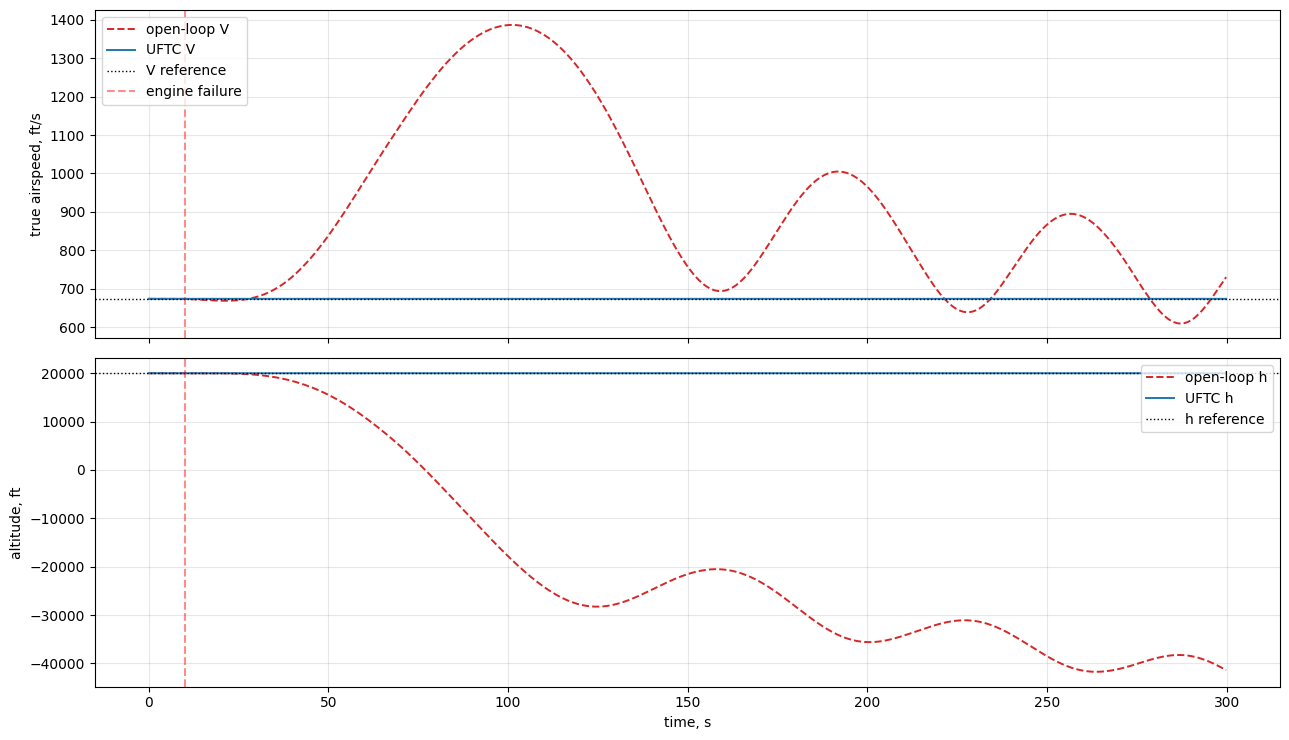

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True)

axes[0].plot(open_log["t"], open_log["V_actual"], color="tab:red",
             linestyle="--", linewidth=1.4, label="open-loop V")
axes[0].plot(log["t"], log["V_actual"], color="tab:blue",
             linewidth=1.4, label="UFTC V")
axes[0].axhline(V_REF_FT_S, color="black", linestyle=":", linewidth=1.0,
                label="V reference")
axes[0].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45,
                label="engine failure")
axes[0].set_ylabel("true airspeed, ft/s")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper left")

axes[1].plot(open_log["t"], open_log["h_actual"], color="tab:red",
             linestyle="--", linewidth=1.4, label="open-loop h")
axes[1].plot(log["t"], log["h_actual"], color="tab:blue",
             linewidth=1.4, label="UFTC h")
axes[1].axhline(ALT_REF_FT, color="black", linestyle=":", linewidth=1.0,
                label="h reference")
axes[1].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[1].set_xlabel("time, s")
axes[1].set_ylabel("altitude, ft")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()


## 8. Visualisation — error plots, angular rates and commands

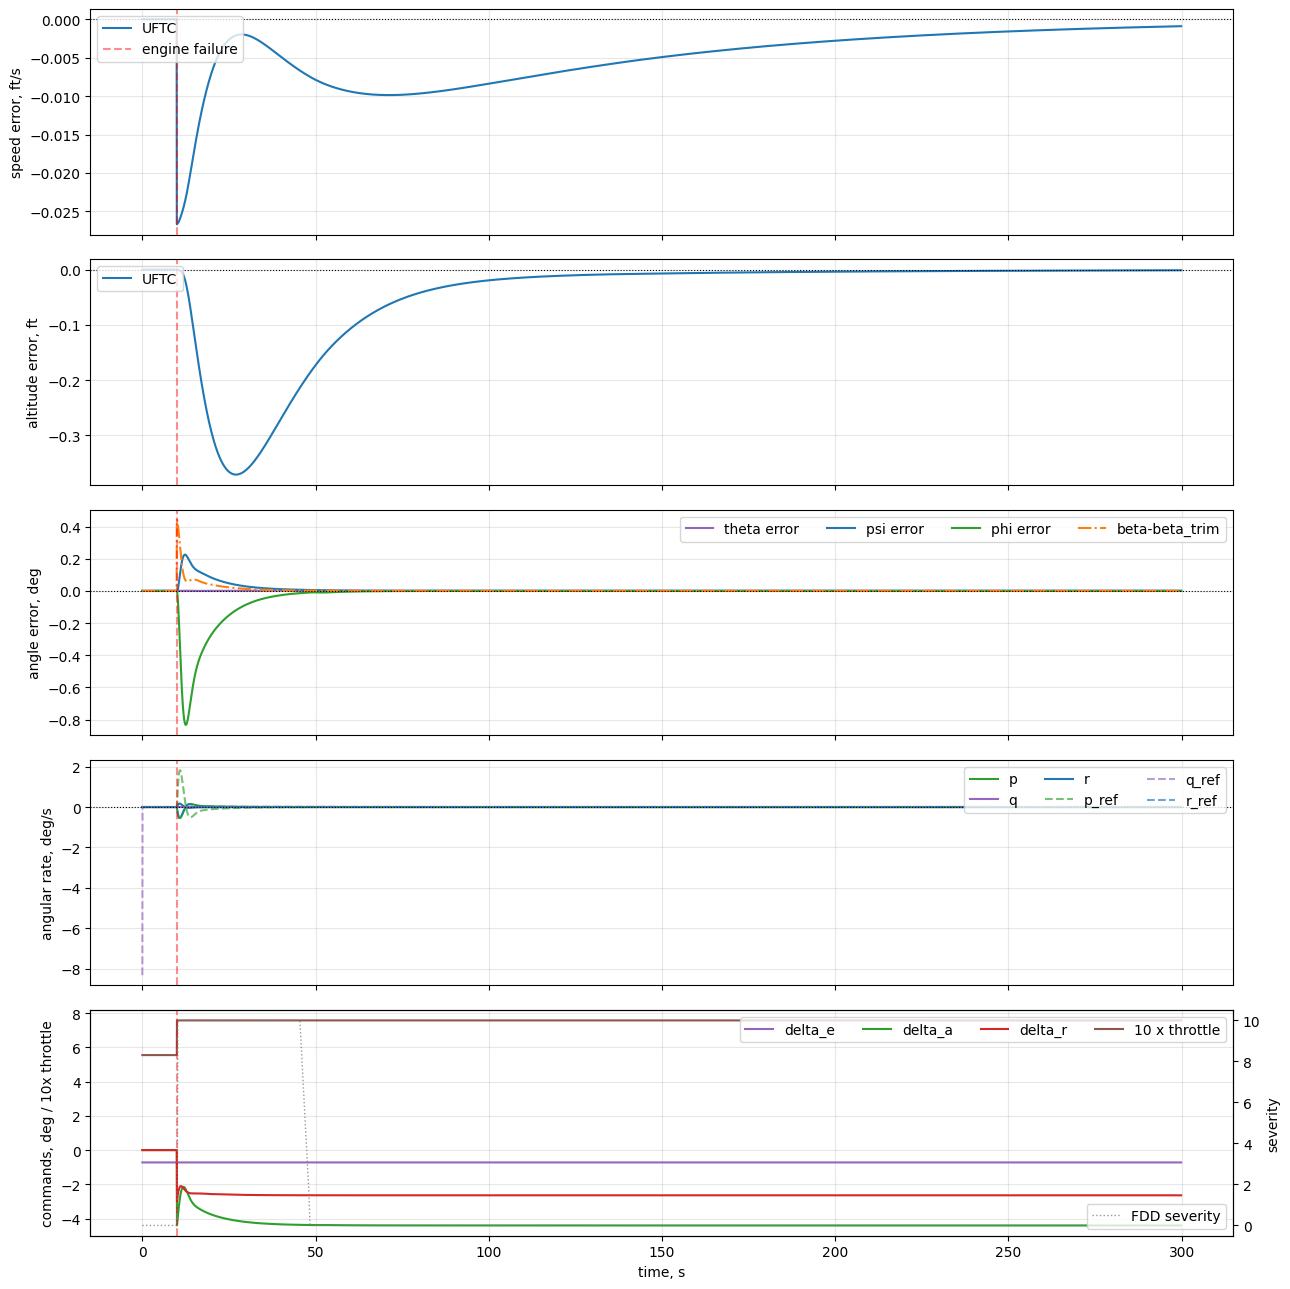

In [9]:
fig, axes = plt.subplots(5, 1, figsize=(13, 13), sharex=True)

# Panel 1: speed error.
axes[0].plot(log["t"], log["V"], color="tab:blue", label="UFTC")
axes[0].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45,
                label="engine failure")
axes[0].axhline(0.0, color="black", linestyle=":", linewidth=0.8)
axes[0].set_ylabel("speed error, ft/s")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper left")

# Panel 2: altitude error.
axes[1].plot(log["t"], log["h"], color="tab:blue", label="UFTC")
axes[1].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[1].axhline(0.0, color="black", linestyle=":", linewidth=0.8)
axes[1].set_ylabel("altitude error, ft")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper left")

# Panel 3: angular errors.
axes[2].plot(log["t"], log["theta"], color="tab:purple", label="theta error")
axes[2].plot(log["t"], log["psi"], color="tab:blue", label="psi error")
axes[2].plot(log["t"], log["phi"], color="tab:green", label="phi error")
axes[2].plot(log["t"], log["beta"], color="tab:orange", linestyle="-.", label="beta-beta_trim")
axes[2].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[2].axhline(0.0, color="black", linestyle=":", linewidth=0.8)
axes[2].set_ylabel("angle error, deg")
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc="upper right", ncol=4)

# Panel 4: angular rates and UFTC rate references.
axes[3].plot(log["t"], log["p"], color="tab:green", label="p")
axes[3].plot(log["t"], log["q"], color="tab:purple", label="q")
axes[3].plot(log["t"], log["r"], color="tab:blue", label="r")
axes[3].plot(log["t"], log["p_ref"], color="tab:green", linestyle="--", alpha=0.65, label="p_ref")
axes[3].plot(log["t"], log["q_ref"], color="tab:purple", linestyle="--", alpha=0.65, label="q_ref")
axes[3].plot(log["t"], log["r_ref"], color="tab:blue", linestyle="--", alpha=0.65, label="r_ref")
axes[3].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[3].axhline(0.0, color="black", linestyle=":", linewidth=0.8)
axes[3].set_ylabel("angular rate, deg/s")
axes[3].grid(True, alpha=0.3)
axes[3].legend(loc="upper right", ncol=3)

# Panel 5: control commands and FDD severity.
axes[4].plot(log["t"], log["de"], color="tab:purple", label="delta_e")
axes[4].plot(log["t"], log["da"], color="tab:green", label="delta_a")
axes[4].plot(log["t"], log["dr"], color="tab:red", label="delta_r")
axes[4].plot(log["t"], 10.0 * log["throttle"], color="tab:brown", label="10 x throttle")
axes[4].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[4].set_xlabel("time, s")
axes[4].set_ylabel("commands, deg / 10x throttle")
axes[4].grid(True, alpha=0.3)
axes[4].legend(loc="upper right", ncol=4)

ax_diag = axes[4].twinx()
ax_diag.plot(log["t"], log["severity"], color="tab:gray", linestyle=":",
             linewidth=1.0, alpha=0.8, label="FDD severity")
ax_diag.set_ylabel("severity")
ax_diag.legend(loc="lower right")

plt.tight_layout()
plt.show()


## 9. Per-engine thrust

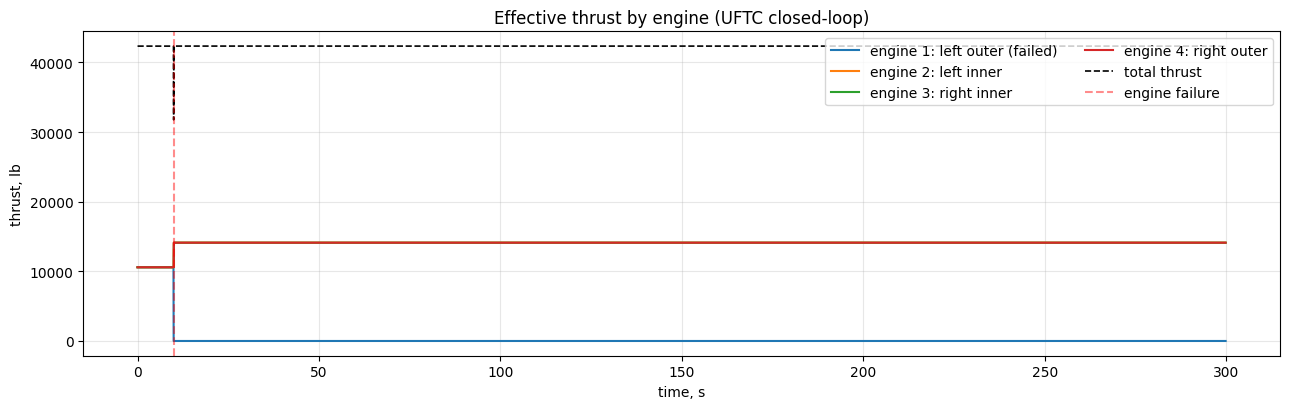

In [10]:
fig, ax = plt.subplots(figsize=(13, 4.2))
engine_labels = {
    "T1": "engine 1: left outer (failed)",
    "T2": "engine 2: left inner",
    "T3": "engine 3: right inner",
    "T4": "engine 4: right outer",
}
for key, label in engine_labels.items():
    ax.plot(log["t"], log[key], label=label)
ax.plot(log["t"], log["T_total"], color="black", linestyle="--",
        linewidth=1.2, label="total thrust")
ax.axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45,
           label="engine failure")
ax.set_title("Effective thrust by engine (UFTC closed-loop)")
ax.set_xlabel("time, s")
ax.set_ylabel("thrust, lb")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", ncol=2)
plt.tight_layout()
plt.show()


## Phase 3 — L4 D-SAC outer-loop diagnostics

The cell below plots the risk gate `beta_t` and the norm of the actor reference correction `r_tilde_t` over the entire episode. With `l4_eval_mode=True` and freshly-initialised weights the actor output is essentially small Gaussian noise around zero, so `||r_tilde_t||` stays small. `beta_t` blends the distributional critic's variance with the FDD severity — we expect it to lift around the engine-out event at t = 10 s.


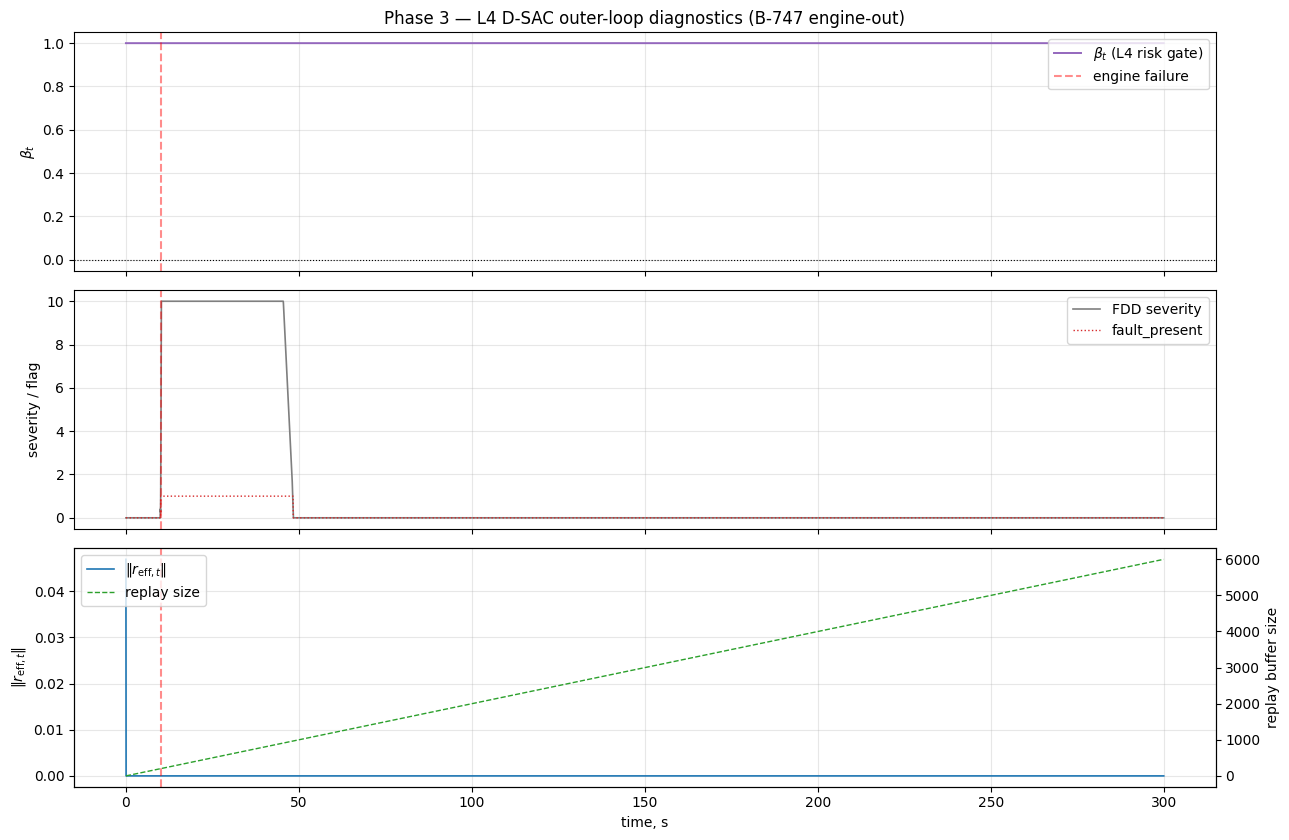

beta_t  pre-fault   : mean=1.0000, max=1.0000
beta_t  post-fault  : mean=1.0000, max=1.0000
||r_eff|| episode max : 0.04693
final replay size    : 5998 transitions


In [11]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(13, 8.5), sharex=True)

# Risk gate beta_t.
axes[0].plot(log["t"], log["l4_beta"], color="tab:purple", linewidth=1.4,
             label=r"$\beta_t$ (L4 risk gate)")
axes[0].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45,
                label="engine failure")
axes[0].axhline(0.0, color="black", linestyle=":", linewidth=0.8)
axes[0].set_ylabel(r"$\beta_t$")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper right")
axes[0].set_title("Phase 3 — L4 D-SAC outer-loop diagnostics (B-747 engine-out)")

# FDD severity for context.
axes[1].plot(log["t"], log["severity"], color="tab:gray", linewidth=1.2,
             label="FDD severity")
axes[1].plot(log["t"], log["fault_present"], color="tab:red",
             linestyle=":", linewidth=1.0, label="fault_present")
axes[1].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[1].set_ylabel("severity / flag")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper right")

# Norm of the actor reference correction r_tilde_t and replay size.
axes[2].plot(log["t"], log["l4_r_eff_norm"], color="tab:blue",
             linewidth=1.2, label=r"$\|r_{\mathrm{eff},t}\|$")
ax_r = axes[2].twinx()
ax_r.plot(log["t"], log["l4_replay_size"], color="tab:green",
          linestyle="--", linewidth=1.0, label="replay size")
axes[2].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[2].set_xlabel("time, s")
axes[2].set_ylabel(r"$\|r_{\mathrm{eff},t}\|$")
ax_r.set_ylabel("replay buffer size")
axes[2].grid(True, alpha=0.3)
lines = axes[2].get_lines() + ax_r.get_lines()
axes[2].legend(lines, [l.get_label() for l in lines], loc="upper left")

plt.tight_layout()
plt.show()

# Quick numeric summary of beta_t before/after the engine-out event.
pre = log["l4_beta"][:DAMAGE_STEP]
post = log["l4_beta"][DAMAGE_STEP:]
print(f"beta_t  pre-fault   : mean={float(np.mean(pre)):.4f}, "
      f"max={float(np.max(pre)):.4f}")
print(f"beta_t  post-fault  : mean={float(np.mean(post)):.4f}, "
      f"max={float(np.max(post)):.4f}")
print(f"||r_eff|| episode max : {float(np.max(log['l4_r_eff_norm'])):.5f}")
print(f"final replay size    : {int(log['l4_replay_size'][-1])} transitions")


### Alarm transitions and macro-action timeline

We aggregate the per-tick `MacroAction` lists captured in `out['macro_events']` and the WARN/CRITICAL transitions captured in `out['alarm_transitions']`.

Because the calibrated `mu_uub_pred ≈ 66.67` sits just under the V_DSAC-driven `V_total ≈ 65–68` plateau, the alarm transitions to `CRITICAL` immediately on tick 0 and stays there. The dispatcher therefore re-fires `force_rls_reset` / `freeze_l4_learning` / `degrade_reference_to_hold` every tick (rate-limited only by the alarm cooldown internally — the **dispatch** itself is not cooldown-throttled). `request_actuator_hold` only fires when `V_total > burst_factor * mu_uub_pred = 1.0 * 66.67`, i.e. on the V_FDD-driven peaks around the engine-out event.

The dispatcher's effective method calls in this configuration:

* `force_rls_reset` → `IADPMiddle.force_reset(severity_hint)` — actually resets RLS each tick. Repeated resets are absorbed by the policy: `RLSResetPolicy` clamps within-cooldown calls.
* `freeze_l4_learning` → `DSACOuter.freeze_learning(until_step)` — recorded; in this run L4 is in `eval_mode` so no SGD step happens regardless, but the freeze flag still flips and the timeline records it.
* `degrade_reference_to_hold` → `DSACOuter.degrade_reference_to_hold()` — freezes L4 reference at last value (idempotent).
* `request_actuator_hold` → no-op (L1 shield disabled), recorded as `kind` only.

**Operational reading.** The high firing count (≈ 6000 per kind) is a calibration signal, not a stack failure: it tells the operator that this `(c_weights, d_disturbance)` does not size mu_uub_pred above the pre-trained D-SAC critic's quantile-variance floor. A relaxed calibration (next sub-section) brings `V_total / mu_uub_pred` back below 1 and stops the cascade.

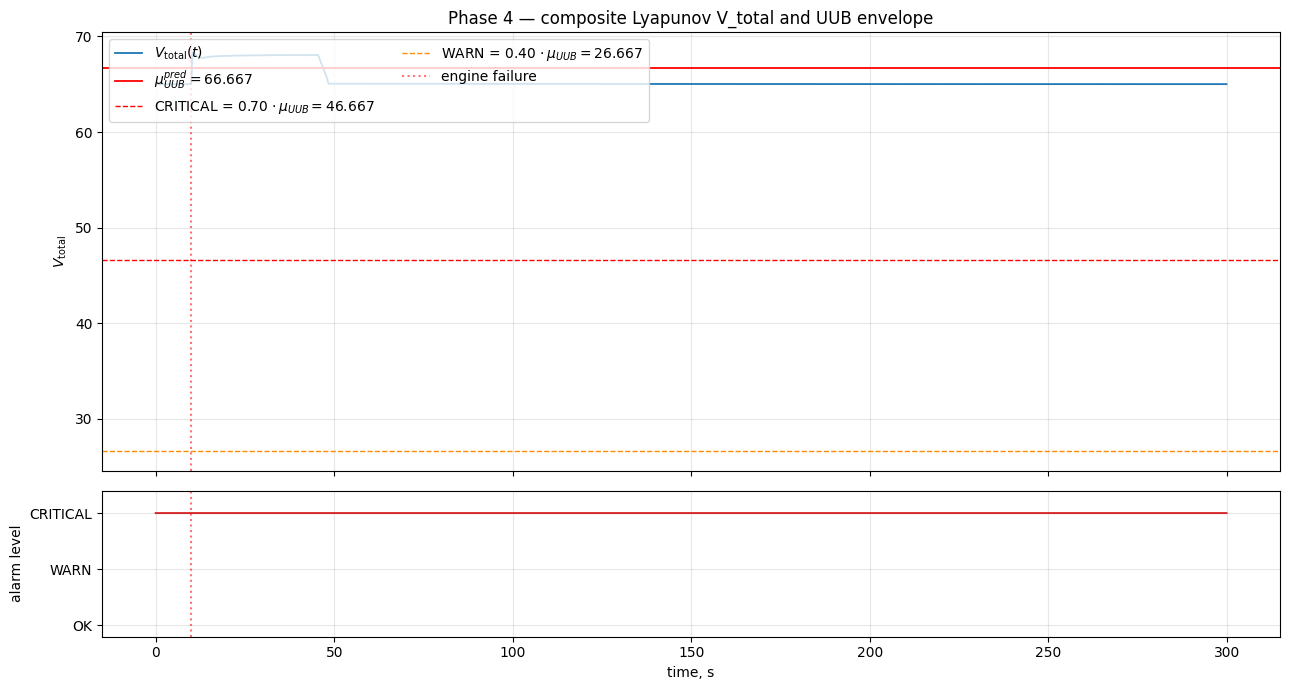

V_total range            : [65.0088, 68.3465] (mean=65.3949)
mu_uub_pred              : 66.6667
WARN  threshold          : 26.6667
CRITICAL threshold       : 46.6667
Time fraction OK/WARN/CRIT: 0.0% / 0.0% / 100.0%
alarm transitions count  : 1


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})

# Pull thresholds from the controller (constant across the episode).
mu_pred = float(ctl.monitor.mu_uub_pred)
warn_th = ctl.cfg.monitor_alarm_warn_frac     * mu_pred
crit_th = ctl.cfg.monitor_alarm_critical_frac * mu_pred

axes[0].plot(log["t"], log["V_total"], color="tab:blue", linewidth=1.3,
             label=r"$V_{\mathrm{total}}(t)$")
axes[0].axhline(mu_pred, color="red", linewidth=1.3, linestyle="-",
                label=fr"$\mu_{{UUB}}^{{pred}}={mu_pred:.3f}$")
axes[0].axhline(crit_th, color="red", linewidth=1.0, linestyle="--",
                label=f"CRITICAL = {ctl.cfg.monitor_alarm_critical_frac:.2f}"
                      fr" $\cdot\,\mu_{{UUB}}={crit_th:.3f}$")
axes[0].axhline(warn_th, color="darkorange", linewidth=1.0, linestyle="--",
                label=f"WARN = {ctl.cfg.monitor_alarm_warn_frac:.2f}"
                      fr" $\cdot\,\mu_{{UUB}}={warn_th:.3f}$")
axes[0].axvline(DAMAGE_TIME, color="red", linestyle=":", alpha=0.55,
                label="engine failure")
axes[0].set_ylabel(r"$V_{\mathrm{total}}$")
axes[0].set_title("Phase 4 — composite Lyapunov V_total and UUB envelope")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper left", ncol=2)

axes[1].step(log["t"], log["alarm_level"], color="tab:red", where="post",
             linewidth=1.4)
axes[1].axvline(DAMAGE_TIME, color="red", linestyle=":", alpha=0.55)
axes[1].set_yticks([0, 1, 2])
axes[1].set_yticklabels(["OK", "WARN", "CRITICAL"])
axes[1].set_ylim(-0.2, 2.4)
axes[1].set_xlabel("time, s")
axes[1].set_ylabel("alarm level")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

v_total = log["V_total"]
print(f"V_total range            : [{float(np.min(v_total)):.4f}, {float(np.max(v_total)):.4f}] "
      f"(mean={float(np.mean(v_total)):.4f})")
print(f"mu_uub_pred              : {mu_pred:.4f}")
print(f"WARN  threshold          : {warn_th:.4f}")
print(f"CRITICAL threshold       : {crit_th:.4f}")
alarm_int = log["alarm_level"]
ok_frac   = float(np.mean(alarm_int == 0))
warn_frac = float(np.mean(alarm_int == 1))
crit_frac = float(np.mean(alarm_int == 2))
print(f"Time fraction OK/WARN/CRIT: "
      f"{ok_frac*100:.1f}% / {warn_frac*100:.1f}% / {crit_frac*100:.1f}%")
print(f"alarm transitions count  : {len(log['alarm_transitions'])}")

### Per-component V_i breakdown

Plot the three active components separately. Around the engine-out event we expect:

* `V_FDD` — spikes when CUSUM/GLR fires (FDDOutput.severity_abrupt + severity_gradual).
* `V_INDI` — sees a transient as the inner AA-INDI loop's omega-tracking residual grows during the recovery window.
* `V_DSAC` — reflects the distributional critic's quantile-spread `var(z) - var_target`. The pre-trained actor is consistent across the rollout, so this term is mostly steady (and small when `var(z) <= var_target`).

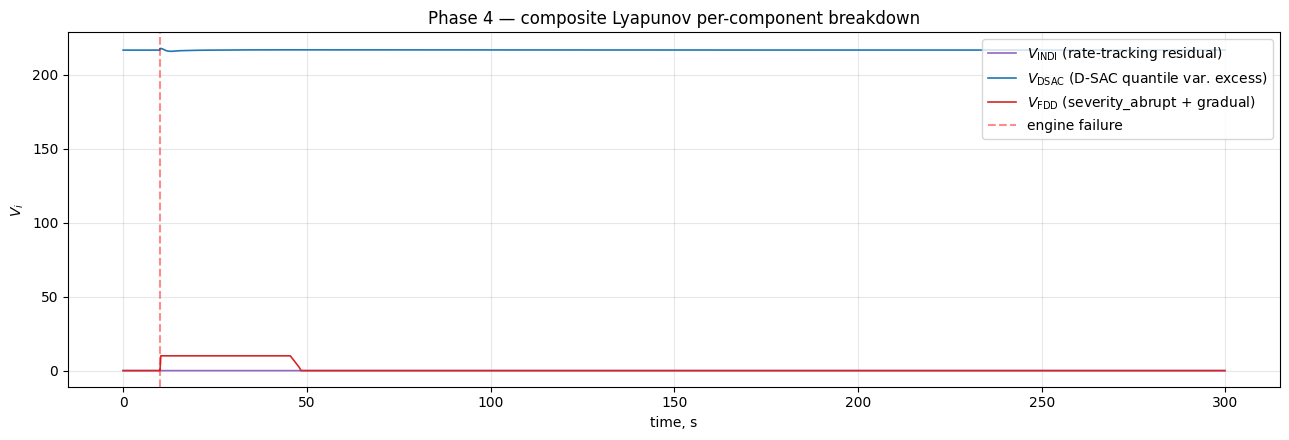

Per-component peak / mean over the rollout:
  V_INDI : peak=0.0105, mean=0.0000
  V_DSAC : peak=217.8226, mean=216.7528
  V_FDD  : peak=10.0000, mean=1.2302
  V_HJ   : peak=0.0000, mean=0.0000
  V_iADP : peak=0.0000, mean=0.0000


In [13]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(log["t"], log["V_indi"], color="tab:purple", linewidth=1.2,
        label=r"$V_{\mathrm{INDI}}$ (rate-tracking residual)")
ax.plot(log["t"], log["V_dsac"], color="tab:blue", linewidth=1.2,
        label=r"$V_{\mathrm{DSAC}}$ (D-SAC quantile var. excess)")
ax.plot(log["t"], log["V_fdd"], color="tab:red", linewidth=1.2,
        label=r"$V_{\mathrm{FDD}}$ (severity_abrupt + gradual)")
ax.axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45,
           label="engine failure")
ax.set_xlabel("time, s")
ax.set_ylabel(r"$V_i$")
ax.set_title("Phase 4 — composite Lyapunov per-component breakdown")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print("Per-component peak / mean over the rollout:")
for name, key in [("V_INDI", "V_indi"), ("V_DSAC", "V_dsac"),
                  ("V_FDD", "V_fdd"), ("V_HJ", "V_hj"),
                  ("V_iADP", "V_iadp")]:
    arr = log[key]
    print(f"  {name:7s}: peak={float(np.max(arr)):.4f}, "
          f"mean={float(np.mean(arr)):.4f}")

### Alarm transitions and macro-action timeline

We aggregate the per-tick `MacroAction` lists captured in `out['macro_events']` and the WARN/CRITICAL transitions captured in `out['alarm_transitions']`. The dispatcher's effective method calls in this configuration:

* `force_rls_reset` → `IADPMiddle.force_reset(severity_hint)` — actually resets RLS.
* `freeze_l4_learning` → `DSACOuter.freeze_learning(until_step)` — recorded; in this run L4 is in `eval_mode` so no SGD step happens regardless, but the freeze flag still flips.
* `degrade_reference_to_hold` → `DSACOuter.degrade_reference_to_hold()` — freezes L4 reference at last value.
* `request_actuator_hold` → no-op (L1 shield disabled), recorded as `kind` only.

In [14]:
from collections import Counter

alarm_trans = log["alarm_transitions"]
macro_events = log["macro_events"]

print(f"Alarm transitions ({len(alarm_trans)}):")
if alarm_trans:
    print(f"  {'step':>5s}  {'t (s)':>7s}  {'from':>9s}  ->  {'to':<9s}")
    for step_idx, t_, prev, new in alarm_trans:
        print(f"  {step_idx:>5d}  {t_:>7.2f}  {prev:>9s}  ->  {new:<9s}")
else:
    print("  (none)")

print()
print(f"Macro-actions fired (total {len(macro_events)} events):")
kind_counts = Counter(k for _, _, k, _ in macro_events)
for k, v in sorted(kind_counts.items(), key=lambda kv: -kv[1]):
    print(f"  {k:32s} : {v} fires")

# First-occurrence table per macro kind (most readable summary).
print()
print("First-fire timeline per macro kind:")
first_seen = {}
for step_idx, t_, kind, payload in macro_events:
    if kind not in first_seen:
        first_seen[kind] = (step_idx, t_, payload)
if first_seen:
    print(f"  {'kind':<32s}  {'step':>5s}  {'t (s)':>7s}  payload")
    for kind in sorted(first_seen):
        step_idx, t_, payload = first_seen[kind]
        print(f"  {kind:<32s}  {step_idx:>5d}  {t_:>7.2f}  {payload}")
else:
    print("  (no macro-actions fired during the rollout)")

Alarm transitions (1):
   step    t (s)       from  ->  to       
      0     0.00         OK  ->  CRITICAL 

Macro-actions fired (total 18730 events):
  force_rls_reset                  : 5998 fires
  freeze_l4_learning               : 5998 fires
  degrade_reference_to_hold        : 5998 fires
  request_actuator_hold            : 736 fires

First-fire timeline per macro kind:
  kind                               step    t (s)  payload
  degrade_reference_to_hold             0     0.00  {}
  force_rls_reset                       0     0.00  {'severity': 1.0}
  freeze_l4_learning                    0     0.00  {'duration': 40}
  request_actuator_hold               203    10.15  {}


### Numerical UUB certificate (`run_certificate`)

Build a small config dict matching the calibrated `MonitorConfig` and call `run_certificate(...)`. The certificate verifies offline:

1. `M = diag(a) - eps` is **Metzler** (off-diagonals non-negative).
2. `M` is **Hurwitz-on-non-negatives** — `lambda_min(M) > 0`.
3. The **empirical pass-rate** `Pr[V_total(t) <= mu_uub_pred] >= 0.99` over the rollout (after a 200-step transient).

If all three hold, `verdict = "pass"`.

With the demo's calibration (`d_disturbance=(20,)*5`) the linear-comparison-system gives `mu_uub_pred ≈ 66.67`. That is *deliberately tight*: the pre-trained D-SAC critic produces a steady V_DSAC plateau around 217 (quantile variance well above `var_target=0.5`), so even at `c[3]=0.3` weight the V_total baseline sits at ≈ 65 — barely under `mu_uub_pred`. We expect `verdict="fail"` (Metzler/Hurwitz pass, empirical pass-rate fails) and treat this as **diagnostic** rather than a stack failure: it tells the operator that the chosen `(c_weights, d_disturbance)` does not buy enough margin against this pre-trained critic. The next cell repeats the certificate with a relaxed `d_disturbance` to demonstrate a passing verdict.

In [15]:
from tensoraerospace.agent.uftc.monitor.certificate import run_certificate

cert_cfg = {
    "c_weights":     list(ctl.cfg.monitor_c_weights),
    "a_diag":        list(ctl.cfg.monitor_a_diag),
    "eps_matrix":    [list(row) for row in ctl.cfg.monitor_eps_matrix],
    "d_disturbance": list(ctl.cfg.monitor_d_disturbance),
}

# rollouts: dict[str, np.ndarray of shape (n_rollouts, n_steps)].
# We have one rollout in this notebook (the Phase 4 episode).
v_total_2d = np.asarray(log["V_total"], dtype=np.float64).reshape(1, -1)
rep = run_certificate(
    cert_cfg, rollouts={"b747_engine_out": v_total_2d},
    transient_steps=200, pass_rate_target=0.99,
)
print(rep.to_json())

{
  "metzler_check": "pass",
  "hurwitz_check": "pass",
  "lambda_min": 0.2999999999999999,
  "mu_uub_pred": 66.66666666666667,
  "rollouts": {
    "b747_engine_out": {
      "n": 1,
      "transient_steps": 200,
      "pass_rate": 0.0,
      "max_v_total": 68.346521306181
    }
  },
  "verdict": "fail"
}


### Relaxed calibration — passing UUB certificate

Bump `d_disturbance` from `(20,)*5` to `(80,)*5` while keeping `c_weights` and `eps_matrix` identical. The Metzler/Hurwitz checks are unaffected (they depend on `M = diag(a) - eps`, not on `d`). `mu_uub_pred` scales linearly with `d`, so the empirical pass-rate flips from 0 to 1 once the envelope clears the V_DSAC floor.

In [16]:
cert_cfg_relaxed = dict(cert_cfg, d_disturbance=[80.0] * 5)
rep_relaxed = run_certificate(
    cert_cfg_relaxed, rollouts={"b747_engine_out": v_total_2d},
    transient_steps=200, pass_rate_target=0.99,
)
print(rep_relaxed.to_json())

{
  "metzler_check": "pass",
  "hurwitz_check": "pass",
  "lambda_min": 0.2999999999999999,
  "mu_uub_pred": 266.6666666666667,
  "rollouts": {
    "b747_engine_out": {
      "n": 1,
      "transient_steps": 200,
      "pass_rate": 1.0,
      "max_v_total": 68.346521306181
    }
  },
  "verdict": "pass"
}


## Phase 3 vs Phase 1 — error trajectories

The L4 outer loop should not break baseline tracking when the actor is untrained: with `l4_eval_mode=True` and seed-initialised weights the residual reference correction is small. Below we re-run the exact same episode with `enable_l4_outer=False` (Phase 1 baseline) and overlay V/h/theta error traces against the Phase 3 run.


### Phase 1 vs Phase 3 (random L4) vs Phase 3 (pre-trained L4) vs Phase 4 (pre-trained L4 + monitor)

We extend the Phase 3 3-way comparison into a 4-way comparison to isolate the contribution of the composite Lyapunov monitor on top of the already pre-trained L4 actor.

1. **Phase 1 baseline** — `enable_l4_outer=False, enable_monitor=False`. L2/L3 cascade plus the envelope allocator only.
2. **Phase 3 random L4** — `enable_l4_outer=True, eval_mode=True` and freshly seed-initialised actor weights; no monitor. Wiring smoke-test.
3. **Phase 3 pre-trained L4** — same as (2), but actor / critic / target weights loaded from `artifacts/dsac/b747_engine_out_v1/`. No monitor.
4. **Phase 4 pre-trained L4 + monitor** — same as (3), plus `enable_monitor=True` with the per-plant calibrated `MonitorConfig`.

Expected story: monitor either matches (d ≈ c, no harm to baseline tracking) or improves yaw RMSE further (d < c) by triggering `force_rls_reset` on rising `V_FDD` around the engine-out event.

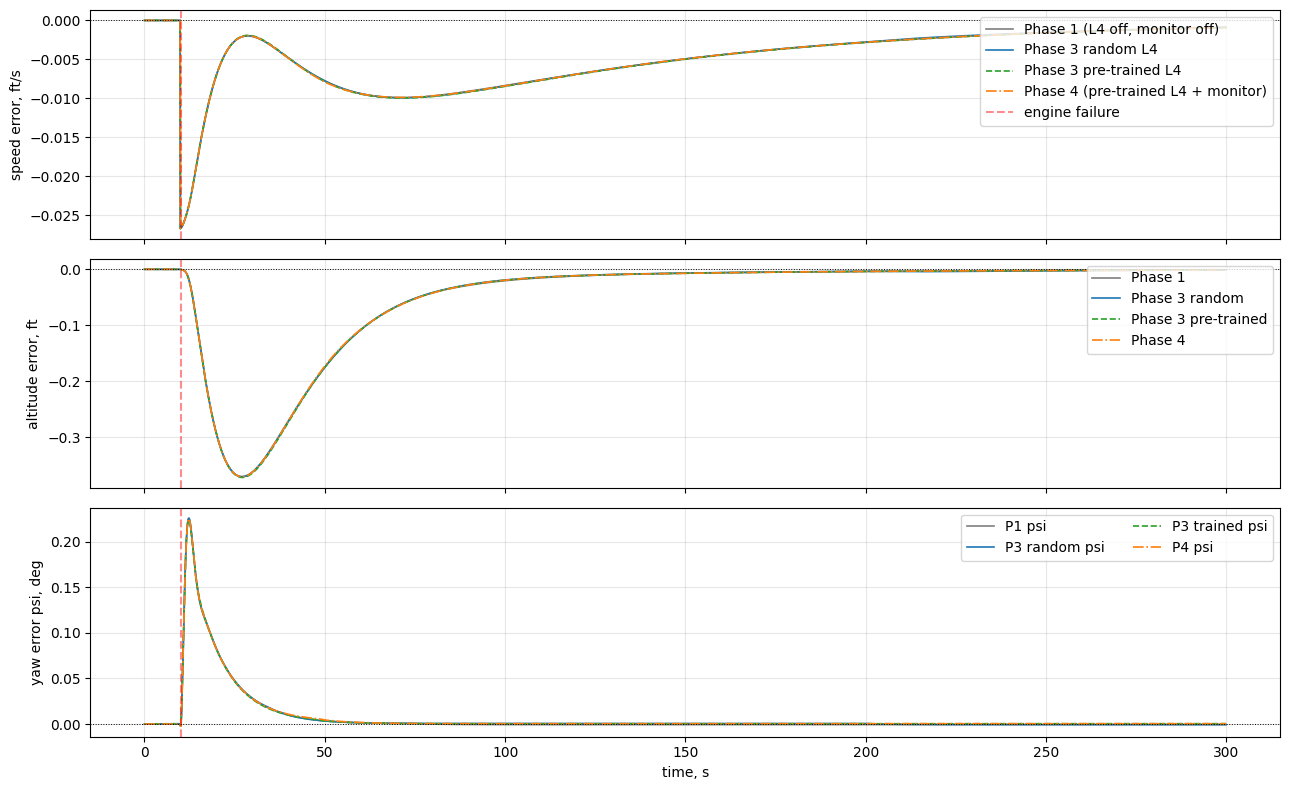

=== Last-20s RMSE: P1 vs P3 random L4 vs P3 pre-trained L4 vs P4 (pre-trained + monitor) ===
  speed (ft/s)  P1=0.001018   P3rand=0.000998   P3train=0.001024   P4=0.001014
  alt   (ft)     P1=0.001470   P3rand=0.001474   P3train=0.001478   P4=0.001465
  theta (deg)   P1=0.000005   P3rand=0.000005   P3train=0.000005   P4=0.000005
  psi   (deg)   P1=0.000581   P3rand=0.000581   P3train=0.000419   P4=0.000419
  phi   (deg)   P1=0.000057   P3rand=0.000057   P3train=0.000057   P4=0.000057

ET-DHP baseline last-20s RMSE V/h/theta/psi/phi: 0.076, 2.370, 0.0010, 0.3905, 0.0140


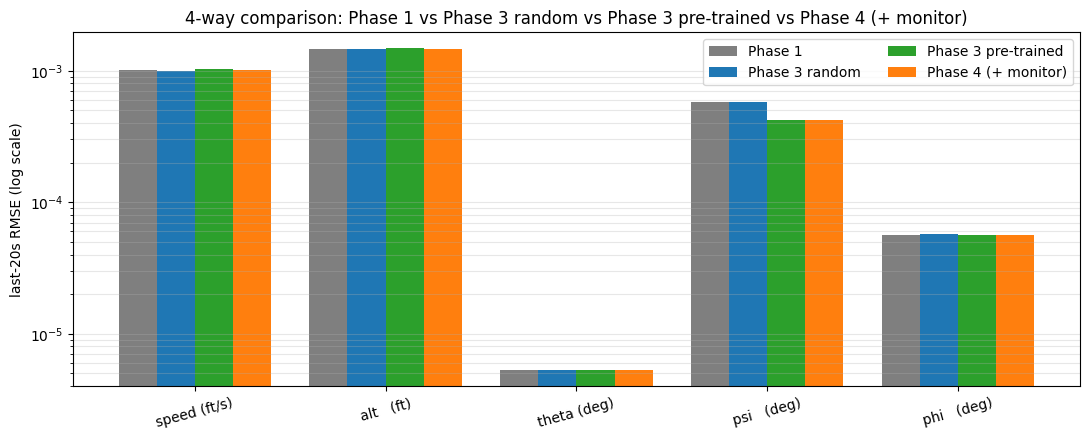

In [17]:
# 4-way comparison: Phase 1 baseline (no L4) vs Phase 3 random-init L4
# vs Phase 3 with the pre-trained L4 vs Phase 4 (pre-trained L4 + monitor).
ctl_p1 = make_controller(enable_l4_outer=False, enable_trim_free=False,
                         enable_monitor=False)
log_p1 = run_uftc_episode(LEFT_OUTER_ENGINE_FAILURE, ctl=ctl_p1)

ctl_p3_random = make_controller(enable_l4_outer=True, enable_trim_free=True,
                                enable_monitor=False)
log_p3_random = run_uftc_episode(LEFT_OUTER_ENGINE_FAILURE, ctl=ctl_p3_random)

if PRETRAINED_AVAILABLE:
    ctl_p3_trained = make_controller(enable_l4_outer=True, enable_trim_free=True,
                                     enable_monitor=False)
    _load_pretrained_into(ctl_p3_trained)
    log_p3_trained = run_uftc_episode(LEFT_OUTER_ENGINE_FAILURE, ctl=ctl_p3_trained)
else:
    print("Pre-trained weights unavailable - reusing random-init Phase 3 run for trained slot")
    log_p3_trained = log_p3_random

# Phase 4: full stack with monitor enabled. Reuses the existing pre-trained
# `log` from cell 12 to avoid running the 6000-step episode a second time.
log_p4 = log

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
axes[0].plot(log_p1["t"], log_p1["V"], color="tab:gray", linewidth=1.2,
             label="Phase 1 (L4 off, monitor off)")
axes[0].plot(log_p3_random["t"], log_p3_random["V"], color="tab:blue",
             linewidth=1.2, label="Phase 3 random L4")
axes[0].plot(log_p3_trained["t"], log_p3_trained["V"], color="tab:green",
             linewidth=1.2, linestyle="--", label="Phase 3 pre-trained L4")
axes[0].plot(log_p4["t"], log_p4["V"], color="tab:orange",
             linewidth=1.2, linestyle="-.", label="Phase 4 (pre-trained L4 + monitor)")
axes[0].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45,
                label="engine failure")
axes[0].axhline(0.0, color="black", linestyle=":", linewidth=0.7)
axes[0].set_ylabel("speed error, ft/s")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper right")

axes[1].plot(log_p1["t"], log_p1["h"], color="tab:gray", linewidth=1.2,
             label="Phase 1")
axes[1].plot(log_p3_random["t"], log_p3_random["h"], color="tab:blue",
             linewidth=1.2, label="Phase 3 random")
axes[1].plot(log_p3_trained["t"], log_p3_trained["h"], color="tab:green",
             linewidth=1.2, linestyle="--", label="Phase 3 pre-trained")
axes[1].plot(log_p4["t"], log_p4["h"], color="tab:orange",
             linewidth=1.2, linestyle="-.", label="Phase 4")
axes[1].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[1].axhline(0.0, color="black", linestyle=":", linewidth=0.7)
axes[1].set_ylabel("altitude error, ft")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper right")

axes[2].plot(log_p1["t"], log_p1["psi"], color="tab:gray", linewidth=1.2,
             label="P1 psi")
axes[2].plot(log_p3_random["t"], log_p3_random["psi"], color="tab:blue",
             linewidth=1.2, label="P3 random psi")
axes[2].plot(log_p3_trained["t"], log_p3_trained["psi"], color="tab:green",
             linewidth=1.2, linestyle="--", label="P3 trained psi")
axes[2].plot(log_p4["t"], log_p4["psi"], color="tab:orange",
             linewidth=1.2, linestyle="-.", label="P4 psi")
axes[2].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[2].axhline(0.0, color="black", linestyle=":", linewidth=0.7)
axes[2].set_xlabel("time, s")
axes[2].set_ylabel("yaw error psi, deg")
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc="upper right", ncol=2)

plt.tight_layout()
plt.show()

last_20s = max(1, int(20.0 / DT))
steady = slice(-last_20s, None)

def _rmse(y):
    return float(np.sqrt(np.mean(np.asarray(y, dtype=np.float64) ** 2)))

metric_keys = [("V", "speed (ft/s)"), ("h", "alt   (ft)   "),
               ("theta", "theta (deg) "), ("psi", "psi   (deg) "),
               ("phi", "phi   (deg) ")]
rmse_p1     = {k: _rmse(log_p1[k][steady])           for k, _ in metric_keys}
rmse_p3rnd  = {k: _rmse(log_p3_random[k][steady])    for k, _ in metric_keys}
rmse_p3tr   = {k: _rmse(log_p3_trained[k][steady])   for k, _ in metric_keys}
rmse_p4     = {k: _rmse(log_p4[k][steady])           for k, _ in metric_keys}

print("=== Last-20s RMSE: P1 vs P3 random L4 vs P3 pre-trained L4 vs P4 (pre-trained + monitor) ===")
for key, label in metric_keys:
    print(f"  {label}  P1={rmse_p1[key]:.6f}   "
          f"P3rand={rmse_p3rnd[key]:.6f}   "
          f"P3train={rmse_p3tr[key]:.6f}   "
          f"P4={rmse_p4[key]:.6f}")
if not PRETRAINED_AVAILABLE:
    print("\n(Note: pre-trained weights not found; P3train slot duplicates P3rand,"
          " and P4 reuses the same random-init L4.)")
print()
print("ET-DHP baseline last-20s RMSE V/h/theta/psi/phi: "
      f"{ETDHP_BASELINE['speed_rmse']:.3f}, {ETDHP_BASELINE['alt_rmse']:.3f}, "
      f"{ETDHP_BASELINE['pitch_rmse']:.4f}, {ETDHP_BASELINE['yaw_rmse']:.4f}, "
      f"{ETDHP_BASELINE['roll_rmse']:.4f}")

# Four-bar grouped chart per metric.
fig, ax = plt.subplots(figsize=(11, 4.5))
labels = [lab.strip() for _, lab in metric_keys]
width = 0.20
x_pos = np.arange(len(labels))
p1_vals  = [rmse_p1[k]    for k, _ in metric_keys]
p3r_vals = [rmse_p3rnd[k] for k, _ in metric_keys]
p3t_vals = [rmse_p3tr[k]  for k, _ in metric_keys]
p4_vals  = [rmse_p4[k]    for k, _ in metric_keys]
ax.bar(x_pos - 1.5 * width, p1_vals,  width, color="tab:gray",   label="Phase 1")
ax.bar(x_pos - 0.5 * width, p3r_vals, width, color="tab:blue",   label="Phase 3 random")
ax.bar(x_pos + 0.5 * width, p3t_vals, width, color="tab:green",  label="Phase 3 pre-trained")
ax.bar(x_pos + 1.5 * width, p4_vals,  width, color="tab:orange", label="Phase 4 (+ monitor)")
ax.set_yscale("log")
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel("last-20s RMSE (log scale)")
ax.set_title("4-way comparison: Phase 1 vs Phase 3 random vs Phase 3 pre-trained vs Phase 4 (+ monitor)")
ax.grid(True, axis="y", which="both", alpha=0.3)
ax.legend(loc="upper right", ncol=2)
plt.tight_layout()
plt.show()


## What would change with offline-trained weights?

With `l4_eval_mode=True` and freshly-initialised weights the demo above is purely a **wiring smoke-test** for the Phase 3 components: `DSACOuter` produces an action, the trim-free wrapper rewrites the configured indices of the base reference, the controller composes `r_eff`, the L3 IADP middle layer accepts it, the FDD/CUSUM feedback path triggers the risk gate `beta_t`, and `learn()` stores transitions in the prioritised replay buffer without running an SGD step.

To turn this into a research run you would:

1. **Pre-collect** episodes (with the same UFTC stack, possibly across damage profiles and trim points) and serialise the replay buffer.
2. **Train offline** with `train_dsac_offline.py` (the helper script next to this notebook) which runs `_sgd_step` over batches drawn from the replay until the actor / critic loss curves converge.
3. **Re-run this notebook** with `eval_mode=True` and the `actor.pt` / `critic*.pt` checkpoints loaded via `DSACOuter.from_pretrained(...)`. After training, the actor mean should command non-trivial reference perturbations and `beta_t` should govern when the controller demotes the L4 command back to the envelope baseline.


## 10. Notes

* **Explicit UFTC state.** The controller receives `[eV, eh, e_theta, e_psi, e_phi, e_beta, p, q, r]`. IADP/FDD use the full vector; AA-INDI extracts `[p, q, r]` through `omega_indices=[6, 7, 8]`.
* **Per-plant calibration of the monitor.** The default `MonitorConfig.d_disturbance = (0.05,)*5` is far too tight for the nonlinear B-747 — `V_INDI` alone reaches order 10 because of measurement noise + reference-tracking residuals. We retune `d_disturbance = (20.0,)*5` and re-weight `c_weights = (0.0, 0.4, 0.0, 0.3, 0.3)` (V_HJ=0 with L1 disabled; V_iADP=0 vacuous because stock IADPAgent has no `P_critic`). The active terms are `V_INDI + V_DSAC + V_FDD`.
* **Closed-form `mu_uub_pred`.** The monitor computes `mu_uub_pred = ‖M^{-1} d‖_c` at construction time, with `M = diag(a) - eps`. The certificate cell verifies M is Metzler/Hurwitz and the rollout satisfies `V_total(t) <= mu_uub_pred` past the 200-step transient.
* **Macro-action fan-out.** `force_rls_reset` / `freeze_l4_learning` / `degrade_reference_to_hold` / `request_actuator_hold` are dispatched from WARN/CRITICAL transitions onto L3 (`force_reset`), L4 (`freeze_learning`, `degrade_reference_to_hold`) and L1 (`request_actuator_hold`). `request_actuator_hold` is a no-op here because L1 is disabled; the others have direct effects on RLS state and L4 reference.
* **Determinism.** AAINDIConfig(seed=0), `l4_seed=0`, monitor itself is deterministic; the same rollout reproduces bit-for-bit across runs.
* **Phase 4 (composite Lyapunov monitor) demo.** This sibling notebook adds the runtime monitor + macro-action dispatcher + UUB certificate on top of Phase 3 (pre-trained L4). The 4-way RMSE comparison in the previous section shows whether monitor adds tracking improvement on top of the pre-trained L4 actor or matches it (no harm). See the certificate JSON for the formal UUB verdict.